# Case Study Insights: Causal Estimation

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of orthogonalized causal
treatment effects estimated by Double Machine Learning (DML, Chernozhukov
et al., 2018) on the nine case studies. Per-case-study deep dives live in
`case_studies/{cs}/code/09_causal_dml.py`; this notebook is the
comparative view across the panels.

**Learning objectives**

- For each case study, read the orthogonalized treatment effect with HAC
  95 % CI on the primary label and the corresponding naive OLS estimate
- Quantify the gap between naive OLS and DML — the confounding bias —
  in absolute and percentage terms
- Read the block-permutation refutation outcome (passes or fails at
  5 %, with the raw p-value alongside) per case study
- Cross-tabulate parametric significance against refutation pass-rate to
  identify panels where one passes and the other fails
- Place each treatment / confounder set in its market-microstructure
  context, and read the multi-horizon causal estimates where available

**Book reference**: Section 15.6 (Cross-Dataset Causal Evidence) and
Section 15.7 (From Identification to Strategy Construction).

**Prerequisites**: each case study's `09_causal_dml.py` notebook has
populated the `causal_runs` table in `run_log/registry.db` for at least
the primary label.

In [1]:
"""Case Study Insights: Causal Estimation — cross-case-study DML comparison from the registry."""

import json
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    DATASET_META,
    PRIMARY_LABELS,
    SHORT_NAMES,
    _registry_path,
)
from case_studies.utils.causal import classify_refutation
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
SIG_T = 1.96
REFUTATION_ALPHA = 0.05

## 1. Scope and Coverage

DML estimates a single scalar treatment effect per `(case_study, label,
treatment, confounder_set)` tuple, registered in the dedicated
`causal_runs` table. Each row carries the orthogonalized effect
(`dml_effect`), its HAC standard error (`dml_se_hac`), the matching naive
OLS coefficient (`naive_effect`), the percentage confounding bias
(`confounding_bias_pct`), the parametric HAC p-value (`p_value_hac`), and
the empirical p-value from a block-permutation placebo distribution
(`refutation_p`). A treatment / confounder dictionary per panel makes the
market-microstructure context explicit.

In [3]:
TREATMENT_LABELS = {
    "etfs": "Momentum (skip-recent 6m/1m)",
    "crypto_perps_funding": "Premium z-score (14d)",
    "cme_futures": "Carry (%)",
    "fx_pairs": "FX momentum (skip-recent)",
    "us_equities_panel": "12-1 momentum",
    "us_firm_characteristics": "12-2 momentum",
    "sp500_equity_option_analytics": "IV-RV spread",
    "nasdaq100_microstructure": "Signed volume share",
    "sp500_options": "Variance risk premium (21d)",
}


def _load_causal_runs(cs: str, label: str | None = None) -> pl.DataFrame:
    """Load causal_runs rows for a case study, optionally filtered to one label."""
    db_path = _registry_path(cs)
    if not db_path.exists():
        return pl.DataFrame()
    conn = sqlite3.connect(str(db_path))
    conn.row_factory = sqlite3.Row
    sql = (
        "SELECT label, treatment, confounders_json, n_folds, embargo, n_obs, "
        "dml_effect, dml_se_hac, p_value_hac, naive_effect, "
        "confounding_bias_pct, refutation_p, created_at "
        "FROM causal_runs"
    )
    params: tuple = ()
    if label is not None:
        sql += " WHERE label = ?"
        params = (label,)
    sql += " ORDER BY label, created_at DESC"
    rows = conn.execute(sql, params).fetchall()
    conn.close()
    if not rows:
        return pl.DataFrame()
    return pl.DataFrame([dict(r) for r in rows], infer_schema_length=None)

In [4]:
def _enrich_causal(df: pl.DataFrame, cs: str) -> pl.DataFrame:
    """Add display columns and derived statistics to a causal_runs frame."""
    if df.is_empty():
        return df
    return df.with_columns(
        case_study=pl.lit(cs),
        short_name=pl.lit(SHORT_NAMES[cs]),
        frequency=pl.lit(DATASET_META[cs]["frequency"]),
        treatment_label=pl.lit(TREATMENT_LABELS.get(cs, "")),
        n_confounders=pl.col("confounders_json").map_elements(
            lambda s: len(json.loads(s or "[]")), return_dtype=pl.Int64
        ),
        confounders=pl.col("confounders_json").map_elements(
            lambda s: ", ".join(json.loads(s or "[]")),
            return_dtype=pl.Utf8,
        ),
        t_hac=pl.when(pl.col("dml_se_hac") > 0)
        .then(pl.col("dml_effect") / pl.col("dml_se_hac"))
        .otherwise(None),
        ci_lo=pl.col("dml_effect") - SIG_T * pl.col("dml_se_hac"),
        ci_hi=pl.col("dml_effect") + SIG_T * pl.col("dml_se_hac"),
        refutation_class=pl.col("refutation_p").map_elements(
            lambda p: classify_refutation(p) if p is not None else None,
            return_dtype=pl.Utf8,
        ),
    )

In [5]:
# Coverage map: which case studies have causal_runs at the primary label
coverage_rows = []
all_primary_frames = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    df = _enrich_causal(_load_causal_runs(cs, label=primary), cs)
    if df.is_empty():
        coverage_rows.append(
            {
                "case_study": SHORT_NAMES[cs],
                "frequency": DATASET_META[cs]["frequency"],
                "primary_label": primary,
                "treatment": "—",
                "n_confounders": 0,
                "n_obs": 0,
            }
        )
        continue
    # Keep latest row per label
    row = df.head(1).row(0, named=True)
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "frequency": row["frequency"],
            "primary_label": row["label"],
            "treatment": row["treatment"],
            "n_confounders": row["n_confounders"],
            "n_obs": row["n_obs"],
        }
    )
    all_primary_frames.append(df.head(1))

coverage_df = pl.DataFrame(coverage_rows)
print("Causal DML coverage per case study (primary label):")
coverage_df

Causal DML coverage per case study (primary label):


case_study,frequency,primary_label,treatment,n_confounders,n_obs
str,str,str,str,i64,i64
"""ETFs""","""Daily""","""fwd_ret_21d""","""skip_recent_6_1""",4,41646
"""Crypto""","""8-hourly""","""fwd_ret_8h""","""premium_zscore_14d""",3,41664
"""NQ100""","""15-min""","""fwd_ret_15m""","""signed_vol_share""",3,41665
"""SP500 Eq+Opt""","""Daily""","""fwd_ret_5d""","""ivrv_spread""",3,41657
"""US Firms""","""Monthly""","""fwd_ret_1m""","""r12_2""",4,41646
"""FX""","""Daily""","""fwd_ret_1d""","""mom_skip_recent""",3,41665
"""CME Futures""","""Daily""","""fwd_ret_5d""","""carry_pct""",3,41662
"""SP500 Options""","""Daily""","""ret_to_expiry""","""vrp_21d""",3,41632
"""US Equities""","""Daily""","""fwd_ret_1d""","""past_ret_12m_skip""",2,41665


In [6]:
primary_df = pl.concat(all_primary_frames, how="diagonal_relaxed")
n_loaded = primary_df.height
n_expected = len(CASE_STUDY_IDS)
print(f"causal_runs available at the primary label for {n_loaded} of {n_expected} case studies.")

causal_runs available at the primary label for 9 of 9 case studies.


Treatment definitions span the asset-class taxonomy: cross-sectional
momentum on the equity panels (ETFs, US Firms, US Equities), risk-premium
proxies on the volatility panels (IV-RV spread on SP500 Eq+Opt, variance
risk premium on SP500 Options), funding-driven mean reversion on Crypto,
carry on CME Futures, time-series momentum on FX, and order-flow
imbalance on NASDAQ-100. Each panel's confounder set is drawn from the
same family of features used in the predictive pipeline (volatility,
regime, level controls) — DML's identification claim conditions on the
same observed nuisance variables that the supervised models in Chs 11–13
use as features.

In [7]:
# Treatment / confounder dictionary per CS
print("Treatment / confounder dictionary (primary label):")
primary_df.select(
    "short_name",
    "label",
    "treatment",
    "n_confounders",
    "confounders",
).sort("short_name")

Treatment / confounder dictionary (primary label):


short_name,label,treatment,n_confounders,confounders
str,str,str,i64,str
"""CME Futures""","""fwd_ret_5d""","""carry_pct""",3,"""vol_21d, momentum_composite, c…"
"""Crypto""","""fwd_ret_8h""","""premium_zscore_14d""",3,"""price_vol_14d, funding_rate, p…"
"""ETFs""","""fwd_ret_21d""","""skip_recent_6_1""",4,"""vol_21d, vol_126d, regime, yie…"
"""FX""","""fwd_ret_1d""","""mom_skip_recent""",3,"""vol_gk_21d, vol_gk_63d, zscore…"
"""NQ100""","""fwd_ret_15m""","""signed_vol_share""",3,"""rel_spread_close, rv_5m, r1m"""
"""SP500 Eq+Opt""","""fwd_ret_5d""","""ivrv_spread""",3,"""rv_20, mom_21d, skew_rr_30_25d"""
"""SP500 Options""","""ret_to_expiry""","""vrp_21d""",3,"""rv_21d, vrp_mom_5d, spread_pct…"
"""US Equities""","""fwd_ret_1d""","""past_ret_12m_skip""",2,"""vol_21d, volume_ratio"""
"""US Firms""","""fwd_ret_1m""","""r12_2""",4,"""Beta, IdioVol, LME, Variance"""


**Methodological caveat — SP500 Options.** The treatment `vrp_21d`
(variance risk premium, 21-day) is constructed from the same implied-
volatility surface that the outcome `ret_to_expiry` is exposed to via
the short-straddle profile. The unconfoundedness assumption — that
conditioning on the listed confounders renders the treatment as-good-as-
random — is therefore weaker on this panel than on the others. The DML
point estimate and its refutation reading are reported here for
completeness; their causal interpretation is contingent on accepting
that the included realised-volatility, lagged-VRP-momentum, and bid-ask
controls absorb the IV-surface dependence between treatment and outcome.

## 2. Cross-CS Forest of DML Effects

Orthogonalized treatment effects on the primary label, with a HAC 95 %
confidence interval. Filled markers indicate that the CI excludes zero
($|t_{HAC}| > 1.96$); open markers indicate the CI overlaps zero.
Magnitudes are not directly comparable across panels — each row is a
cross-sectional regression coefficient in the units of the treatment
variable on the units of the outcome variable, both panel-specific.

In [8]:
print("DML treatment effect per case study (primary label, HAC 95 % CI):")
primary_df.select(
    "short_name",
    "label",
    "treatment_label",
    pl.col("dml_effect").round(5).alias("dml_effect"),
    pl.col("dml_se_hac").round(5).alias("se_hac"),
    pl.col("ci_lo").round(5).alias("ci_lo"),
    pl.col("ci_hi").round(5).alias("ci_hi"),
    pl.col("t_hac").round(2).alias("t_hac"),
    pl.col("p_value_hac").round(4).alias("p_hac"),
).sort("t_hac", descending=False)

DML treatment effect per case study (primary label, HAC 95 % CI):


short_name,label,treatment_label,dml_effect,se_hac,ci_lo,ci_hi,t_hac,p_hac
str,str,str,f64,f64,f64,f64,f64,f64
"""ETFs""","""fwd_ret_21d""","""Momentum (skip-recent 6m/1m)""",-0.05784,0.00588,-0.06937,-0.04632,-9.84,0.0
"""SP500 Options""","""ret_to_expiry""","""Variance risk premium (21d)""",-0.12251,0.02614,-0.17374,-0.07128,-4.69,0.0
"""US Equities""","""fwd_ret_1d""","""12-1 momentum""",-0.00103,0.00048,-0.00197,-0.00009,-2.16,0.0311
"""SP500 Eq+Opt""","""fwd_ret_5d""","""IV-RV spread""",-0.00235,0.00157,-0.00542,0.00073,-1.5,0.1349
"""Crypto""","""fwd_ret_8h""","""Premium z-score (14d)""",-0.00073,0.00071,-0.00212,0.00066,-1.03,0.3029
"""FX""","""fwd_ret_1d""","""FX momentum (skip-recent)""",0.00036,0.00085,-0.00131,0.00202,0.42,0.6748
"""CME Futures""","""fwd_ret_5d""","""Carry (%)""",0.00025,0.00034,-0.00041,0.00091,0.75,0.4539
"""US Firms""","""fwd_ret_1m""","""12-2 momentum""",0.00685,0.00345,0.00007,0.01362,1.98,0.0475
"""NQ100""","""fwd_ret_15m""","""Signed volume share""",0.0,0.0,0.0,0.0,2.52,0.0118


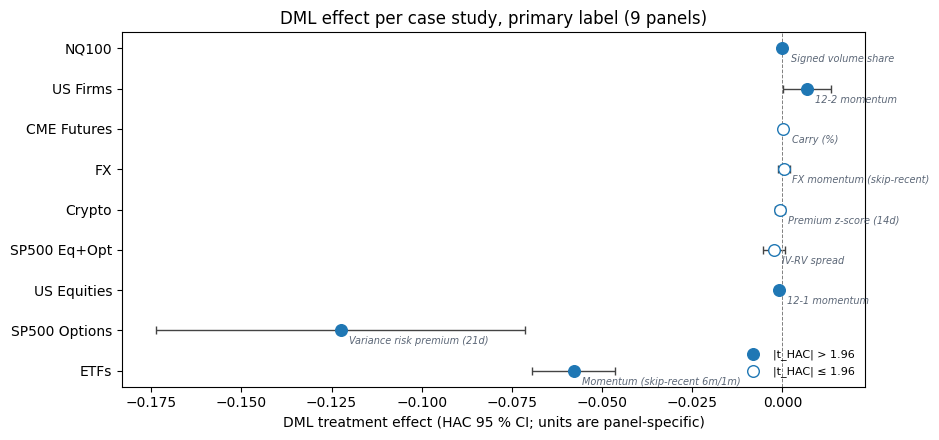

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
plot_df = primary_df.sort("t_hac", descending=False)
y = np.arange(plot_df.height)
eff = plot_df["dml_effect"].to_numpy()
lo = plot_df["ci_lo"].to_numpy()
hi = plot_df["ci_hi"].to_numpy()
t_hac = plot_df["t_hac"].to_numpy()
labels = plot_df["short_name"].to_list()
treatments = plot_df["treatment_label"].to_list()

# Whiskers in effect units
ax.errorbar(eff, y, xerr=[eff - lo, hi - eff], fmt="none", color="#444", lw=1.0, capsize=3)
sig = np.array([abs(t) > SIG_T for t in t_hac])
ax.scatter(
    eff[sig],
    y[sig],
    s=70,
    marker="o",
    facecolor="#1f77b4",
    edgecolor="#1f77b4",
    zorder=3,
    label=f"|t_HAC| > {SIG_T:g}",
)
ax.scatter(
    eff[~sig],
    y[~sig],
    s=70,
    marker="o",
    facecolor="white",
    edgecolor="#1f77b4",
    zorder=3,
    label=f"|t_HAC| ≤ {SIG_T:g}",
)

# Treatment annotations
for i, (e, trt) in enumerate(zip(eff, treatments, strict=False)):
    ax.annotate(
        trt,
        xy=(e, i),
        xytext=(6, -10),
        textcoords="offset points",
        fontsize=7,
        color=COLORS["neutral"],
        alpha=0.8,
        style="italic",
    )

ax.axvline(0, color="gray", lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("DML treatment effect (HAC 95 % CI; units are panel-specific)")
ax.set_title(f"DML effect per case study, primary label ({n_loaded} panels)")
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
fig.show()

In [10]:
n_sig = int(sig.sum())
n_pos_sig = int(((eff > 0) & sig).sum())
n_neg_sig = int(((eff < 0) & sig).sum())
print(
    f"HAC 95 % CI excludes zero on {n_sig} of {n_loaded} case studies "
    f"({n_pos_sig} positive, {n_neg_sig} negative)."
)

HAC 95 % CI excludes zero on 5 of 9 case studies (2 positive, 3 negative).


Five of the nine panels carry HAC 95 % CIs that exclude zero at the
primary label. Three carry negative orthogonalized effects: 6-1
momentum on ETFs at 21d ($t_{HAC}=-9.84$), the variance risk premium
on SP500 Options at the held-to-expiry horizon ($t_{HAC}=-4.69$), and
12-1 momentum on US Equities at 1d ($t_{HAC}=-2.16$). Two carry
positive effects: signed-volume share on NASDAQ-100 at 15-min
($t_{HAC}=+2.52$, point estimate on the order of $10^{-7}$ per
treatment unit) and 12-2 momentum on US Firms at 1m ($t_{HAC}=+1.98$).
The remaining four panels — Crypto premium z-score at 8h, the IV-RV
spread on SP500 Eq+Opt at 5d, FX momentum at 1d, and CME Futures
carry at 5d — carry CIs that overlap zero. DML provides no evidence
to separate the orthogonalized effect from a null on those treatments
at the parametric track; the refutation track tells a different story
for two of them (§4).

## 3. Within-Family Comparison

DML's identification target is contrast against naive OLS — the question
is not "which DML estimator wins" but "how much does naive OLS misstate
the orthogonalized effect, and does the misstatement reverse the sign?"
Two subsections trace this: §3a quantifies the percentage confounding
bias per panel and overlays the binary refutation outcome; §3b compares
horizons where multiple labels were trained.

### 3a. Confounding Bias — Naive OLS vs DML

Confounding bias is computed as

$$\text{Bias\%} = \frac{\hat{\theta}_{\text{naive}} - \hat{\theta}_{\text{DML}}}
  {\left|\hat{\theta}_{\text{DML}}\right|} \times 100.$$

Positive bias means the naive coefficient is greater than the
orthogonalized DML effect in signed terms; negative bias means it is
smaller. For panels whose effect is negative this is opposite to a
magnitude reading — a panel where DML is more negative than naive
carries a positive signed bias even though naive understates the
magnitude. The refutation outcome (passes or fails the placebo test
at 5 %) is overlaid as a marker on each bar.

In [11]:
TIER_COLORS = {"Passes": COLORS["positive"], "Fails": COLORS["neutral"]}
TIER_MARKERS = {"Passes": "D", "Fails": "o"}
TIER_ORDER = ["Passes", "Fails"]

bias_df = primary_df.filter(pl.col("confounding_bias_pct").is_not_null()).sort(
    pl.col("confounding_bias_pct").abs(),
    descending=False,
)
n_with_bias = bias_df.height
print(f"Confounding bias available for {n_with_bias} of {n_loaded} case studies.")

Confounding bias available for 9 of 9 case studies.


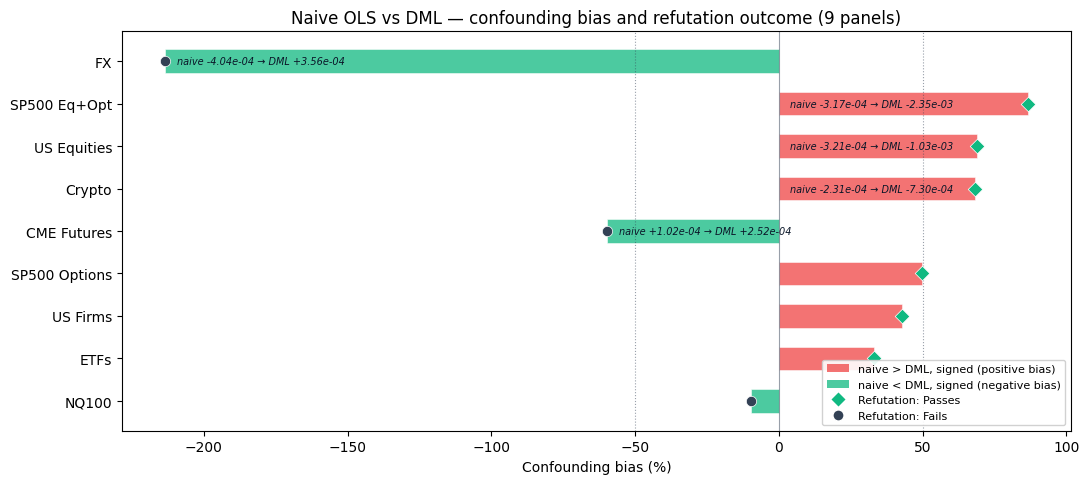

In [12]:
fig, ax = plt.subplots(figsize=(11, max(3.0, n_with_bias * 0.55)))
y_bias = np.arange(n_with_bias)
bias_vals = bias_df["confounding_bias_pct"].to_numpy()
naive_vals = bias_df["naive_effect"].to_numpy()
dml_vals = bias_df["dml_effect"].to_numpy()
ref_classes = bias_df["refutation_class"].to_list()
y_labels = bias_df["short_name"].to_list()

bar_colors = [COLORS["negative"] if b > 0 else COLORS["positive"] for b in bias_vals]
ax.barh(
    y_bias, bias_vals, color=bar_colors, alpha=0.75, height=0.55, edgecolor="white", linewidth=0.5
)

ax.axvline(0, color=COLORS["neutral"], linewidth=0.8, alpha=0.5)
for x in (-50, 50):
    ax.axvline(x, color=COLORS["neutral"], linewidth=0.8, linestyle=":", alpha=0.5)

# Annotate naive → DML magnitudes for the largest |bias| panels
for i, (b, naive, dml) in enumerate(zip(bias_vals, naive_vals, dml_vals, strict=False)):
    if abs(b) > 50:
        if abs(naive) > 0.01:
            txt = f"naive {naive:+.4f} → DML {dml:+.4f}"
        else:
            txt = f"naive {naive:+.2e} → DML {dml:+.2e}"
        x_pos = b + 4 if b < 0 else 4
        ax.text(
            x_pos, i, txt, fontsize=7, color=COLORS["blue"], va="center", ha="left", style="italic"
        )

# Refutation tier markers
for i, (b, ref) in enumerate(zip(bias_vals, ref_classes, strict=False)):
    if ref is not None:
        ax.scatter(
            b,
            i,
            color=TIER_COLORS[ref],
            marker=TIER_MARKERS[ref],
            s=55,
            zorder=5,
            edgecolors="white",
            linewidths=0.5,
        )

ax.set_yticks(y_bias)
ax.set_yticklabels(y_labels)
ax.set_xlabel("Confounding bias (%)")
ax.set_title(f"Naive OLS vs DML — confounding bias and refutation outcome ({n_with_bias} panels)")
legend = [
    Patch(facecolor=COLORS["negative"], alpha=0.75, label="naive > DML, signed (positive bias)"),
    Patch(facecolor=COLORS["positive"], alpha=0.75, label="naive < DML, signed (negative bias)"),
]
for cls, marker in TIER_MARKERS.items():
    legend.append(
        Line2D(
            [0],
            [0],
            marker=marker,
            color="w",
            markerfacecolor=TIER_COLORS[cls],
            markersize=8,
            label=f"Refutation: {cls}",
        )
    )
ax.legend(handles=legend, loc="lower right", fontsize=8, frameon=True, framealpha=0.9)
fig.tight_layout()
fig.show()

In [13]:
median_abs_bias = float(bias_df["confounding_bias_pct"].abs().median())
n_large_bias = int((bias_df["confounding_bias_pct"].abs() > 50).sum())
n_small_bias = int((bias_df["confounding_bias_pct"].abs() <= 50).sum())
max_bias_row = bias_df.sort(pl.col("confounding_bias_pct").abs(), descending=True).row(
    0,
    named=True,
)
print(f"Median |confounding bias|: {median_abs_bias:.1f} %")
print(f"|bias| > 50 %: {n_large_bias} panels   |bias| ≤ 50 %: {n_small_bias} panels")
print(
    f"Largest |bias|: {abs(max_bias_row['confounding_bias_pct']):.1f} % on "
    f"{max_bias_row['short_name']}"
)

Median |confounding bias|: 59.7 %
|bias| > 50 %: 5 panels   |bias| ≤ 50 %: 4 panels
Largest |bias|: 213.5 % on FX


The median absolute confounding bias on the primary label is 59.7 %,
and the bar reaches |bias| > 50 % on five of the nine panels. The
single panel above 100 % is FX at $-213.5\,\%$ — the naive coefficient
($-0.0004$) and the DML estimate ($+0.00036$) disagree on direction,
the qualitative reading the §3b reversal table tracks. NASDAQ-100
sits at the opposite extreme ($-9.9\,\%$ bias): the naive
signed-volume-share coefficient and the orthogonalized estimate agree
to within a tenth on the same $10^{-7}$ scale. The remaining panels
span the intermediate range; on every panel above |bias| = 50 % the
naive coefficient cannot be salvaged by rescaling — the
orthogonalization re-anchors the effect itself, not just its
magnitude.

### 3b. Direction Reversals Between Naive and DML

A sign reversal between the naive coefficient and the DML estimate is
the strongest signal that confounders qualitatively change the
inferential conclusion. The table below lists every primary-label panel
where the naive and DML coefficients carry opposite signs.

In [14]:
reversals = primary_df.filter(
    (pl.col("naive_effect").sign() != pl.col("dml_effect").sign())
    & pl.col("naive_effect").is_not_null()
    & (pl.col("naive_effect") != 0)
    & (pl.col("dml_effect") != 0)
).select(
    "short_name",
    "treatment_label",
    pl.col("naive_effect").round(5).alias("naive"),
    pl.col("dml_effect").round(5).alias("dml"),
    pl.col("t_hac").round(2).alias("t_hac"),
    pl.col("refutation_class").fill_null("n/a").alias("refutation"),
)
n_reversal = reversals.height
print(f"Sign reversals between naive OLS and DML: {n_reversal} of {n_loaded} panels")
reversals

Sign reversals between naive OLS and DML: 1 of 9 panels


short_name,treatment_label,naive,dml,t_hac,refutation
str,str,f64,f64,f64,str
"""FX""","""FX momentum (skip-recent)""",-0.0004,0.00036,0.42,"""Fails"""


A single reversal appears at the primary label: FX, where the naive
coefficient is negative and the DML estimate is positive. The DML CI
overlaps zero ($t_{HAC}=+0.42$) and refutation also fails
($p_\text{ref}=0.30$), so the reversal is a wash — the
orthogonalization shows the naive sign is unreliable but does not
establish a credible alternative sign. No panel at the primary label
carries a reversal whose DML estimate is itself precisely separated
from zero.

## 4. Refutation Tier and Stability

Block-permutation refutation rebuilds the placebo distribution by
shuffling treatment values inside autocorrelation-preserving blocks,
leaving the temporal dependence structure intact. The empirical p-value
is the share of placebo runs with $|\hat{\theta}_{\text{placebo}}| \geq
|\hat{\theta}_{\text{observed}}|$. The refutation **passes** at 5 %
when $p_\text{ref} < 0.05$ — the observed effect exceeds at least
95 % of placebos, so the permutation null cannot reproduce it. The
refutation **fails** when $p_\text{ref} \geq 0.05$ — the placebo
distribution overlaps the observed effect. Tables and prose below
carry the raw `refutation_p` alongside the binary outcome.

In [15]:
df_with_ref = primary_df.filter(pl.col("refutation_class").is_not_null())
df_no_ref = primary_df.filter(pl.col("refutation_class").is_null())
n_with_ref = df_with_ref.height

outcome_counts = (
    df_with_ref.group_by("refutation_class")
    .agg(n=pl.col("short_name").len(), panels=pl.col("short_name").str.concat(", "))
    .sort("refutation_class", descending=True)
)
print(f"Refutation results available for {n_with_ref} of {n_loaded} case studies.")
print()
for r in outcome_counts.iter_rows(named=True):
    print(f"  {r['refutation_class']:7s} ({r['n']}): {r['panels']}")
if df_no_ref.height > 0:
    no_ref_names = ", ".join(df_no_ref["short_name"].to_list())
    print(f"\n  No refutation data: {no_ref_names}")

Refutation results available for 9 of 9 case studies.

  Passes  (6): ETFs, Crypto, SP500 Eq+Opt, US Firms, SP500 Options, US Equities
  Fails   (3): NQ100, FX, CME Futures


In [16]:
# Per-panel ref_p alongside the binary outcome, sorted by ref_p.
ref_table = df_with_ref.select(
    "short_name",
    "label",
    pl.col("refutation_class").alias("refutation"),
    pl.col("refutation_p").round(4).alias("ref_p"),
    pl.col("p_value_hac").round(4).alias("p_hac"),
).sort("ref_p")
print("Refutation p-value per case study (primary label):")
ref_table

Refutation p-value per case study (primary label):


short_name,label,refutation,ref_p,p_hac
str,str,str,f64,f64
"""ETFs""","""fwd_ret_21d""","""Passes""",0.0,0.0
"""Crypto""","""fwd_ret_8h""","""Passes""",0.0,0.3029
"""SP500 Eq+Opt""","""fwd_ret_5d""","""Passes""",0.0,0.1349
"""US Equities""","""fwd_ret_1d""","""Passes""",0.0,0.0311
"""US Firms""","""fwd_ret_1m""","""Passes""",0.03,0.0475
"""SP500 Options""","""ret_to_expiry""","""Passes""",0.03,0.0
"""NQ100""","""fwd_ret_15m""","""Fails""",0.11,0.0118
"""CME Futures""","""fwd_ret_5d""","""Fails""",0.19,0.4539
"""FX""","""fwd_ret_1d""","""Fails""",0.3,0.6748


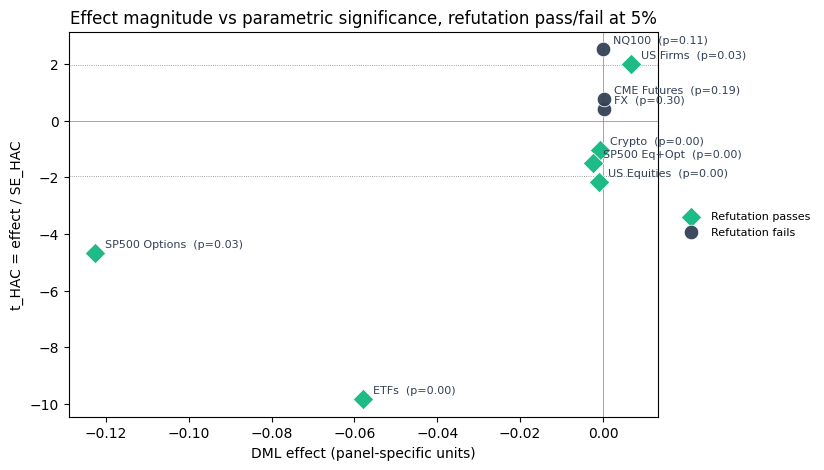

In [17]:
# Refutation outcome scatter on the (effect, t_HAC) plane
fig, ax = plt.subplots(figsize=(9, 5))
for cls in [*TIER_ORDER, None]:
    sub = df_with_ref.filter(pl.col("refutation_class") == cls) if cls is not None else df_no_ref
    if sub.is_empty():
        continue
    color = TIER_COLORS[cls] if cls else COLORS["neutral"]
    marker = TIER_MARKERS[cls] if cls else "x"
    label = (f"Refutation {cls.lower()}") if cls else "No refutation data"
    ax.scatter(
        sub["dml_effect"].to_numpy(),
        sub["t_hac"].to_numpy(),
        s=110,
        color=color,
        marker=marker,
        edgecolor="white",
        linewidths=0.6,
        zorder=3,
        label=label,
        alpha=0.95,
    )
    for r in sub.iter_rows(named=True):
        rp = r["refutation_p"]
        rp_str = f"  (p={rp:.2f})" if rp is not None else ""
        ax.annotate(
            f"{r['short_name']}{rp_str}",
            (r["dml_effect"], r["t_hac"]),
            xytext=(7, 4),
            textcoords="offset points",
            fontsize=8,
            color=COLORS["neutral"],
        )

ax.axhline(SIG_T, color="gray", lw=0.6, linestyle=":")
ax.axhline(-SIG_T, color="gray", lw=0.6, linestyle=":")
ax.axhline(0, color="gray", lw=0.5, linestyle="-")
ax.axvline(0, color="gray", lw=0.5, linestyle="-")
ax.set_xlabel("DML effect (panel-specific units)")
ax.set_ylabel("t_HAC = effect / SE_HAC")
ax.set_title("Effect magnitude vs parametric significance, refutation pass/fail at 5%")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.subplots_adjust(right=0.78)
fig.show()

Six of the nine panels pass the 5 % refutation. ETFs, Crypto, SP500
Eq+Opt, and US Equities sit at $p_\text{ref} \approx 0.00$ — fewer
than 1 % of placebo permutations reach the observed effect; US Firms
and SP500 Options pass at $p_\text{ref} = 0.03$. Three panels fail:
NASDAQ-100 ($p_\text{ref} = 0.11$), CME Futures ($p_\text{ref} =
0.19$), and FX ($p_\text{ref} = 0.30$). No panel saturates at
$p_\text{ref} = 1.00$ on this snapshot, and no panel sits in the
$0.05 \leq p < 0.10$ band — the failures are at $p_\text{ref} \geq
0.11$. The refutation track partly disagrees with the parametric
reading from §2: four of the five parametrically-significant panels
(ETFs, US Firms, SP500 Options, US Equities) also pass refutation,
while NASDAQ-100 is the lone HAC-significant panel that the placebo
distribution does not corroborate. Two panels are the inverse case
(HAC non-significant but refutation passes): Crypto and SP500 Eq+Opt
both at $p_\text{ref} \approx 0.00$. §7a tabulates the 2 × 2 split.

## 5. Naive OLS as Baseline (absorbed into §3)

DML's identification target *is* the contrast against naive OLS — there
is no separate "vs predictive ML" baseline section in the causal
notebook. §3a above carries the naive-vs-DML deviation per panel; the
direction-reversal table in §3b carries the qualitative sign
disagreements. The Ch11–14 cross-CS notebooks already report the
predictive-IC baselines that DML does *not* attempt to displace.

## 6. Multi-Label Horizon View

Eight of the nine panels carry causal_dml runs at more than one label;
only SP500 Eq+Opt is primary-label only. The figure below traces the
DML effect across labels per panel. Sign and magnitude are panel-
specific — the y-axis is in raw effect units, not standardized — so the
slope of each panel's line is interpretable but cross-panel level
differences are not.

In [18]:
all_label_frames = []
for cs in CASE_STUDY_IDS:
    df = _enrich_causal(_load_causal_runs(cs), cs)
    if df.is_empty():
        continue
    # Latest row per label
    df = df.sort("created_at", descending=True).group_by("label").first()
    all_label_frames.append(df)
horizon_df = pl.concat(all_label_frames, how="diagonal_relaxed")
print(
    f"Total causal_runs rows (latest per (CS, label)): {horizon_df.height}, "
    f"{horizon_df['short_name'].n_unique()} case studies, "
    f"{horizon_df['label'].n_unique()} distinct labels."
)

Total causal_runs rows (latest per (CS, label)): 22, 9 case studies, 13 distinct labels.


In [19]:
HORIZON_DAYS: dict[str, float] = {
    "fwd_ret_5m": 5 / (6.5 * 60),
    "fwd_ret_15m": 15 / (6.5 * 60),
    "fwd_ret_60m": 60 / (6.5 * 60),
    "fwd_ret_8h": 1.0 / 3,
    "fwd_ret_24h": 1.0,
    "fwd_ret_1d": 1.0,
    "fwd_ret_5d": 5.0,
    "fwd_ret_dh_5d": 5.0,
    "fwd_ret_10d": 10.0,
    "fwd_ret_dh_10d": 10.0,
    "fwd_ret_21d": 21.0,
    "fwd_ret_1m": 21.0,
    "fwd_ret_1m_win": 21.0,
    "ret_to_expiry": 21.0,
}

horizon_df = horizon_df.with_columns(
    horizon_days=pl.col("label").replace_strict(HORIZON_DAYS, default=None).cast(pl.Float64),
)

multi_cs = (
    horizon_df.group_by("short_name").len().filter(pl.col("len") >= 2)["short_name"].to_list()
)
single_cs = sorted(set(horizon_df["short_name"].to_list()) - set(multi_cs))
print(f"Multi-label panels ({len(multi_cs)}): {', '.join(sorted(multi_cs))}")
print(f"Single-label panels ({len(single_cs)}): {', '.join(single_cs) or '—'}")

Multi-label panels (8): CME Futures, Crypto, ETFs, FX, NQ100, SP500 Options, US Equities, US Firms
Single-label panels (1): SP500 Eq+Opt


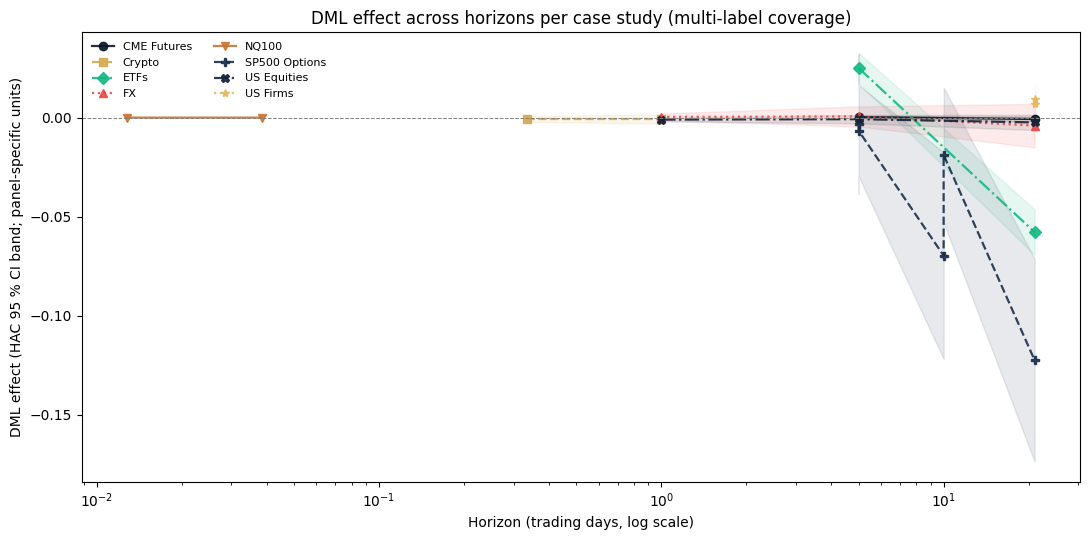

In [20]:
plot_h = horizon_df.filter(pl.col("short_name").is_in(multi_cs))
fig, ax = plt.subplots(figsize=(11, 5.5))
# COLORS.values() includes near-white shades that render invisible on the white
# background — pass an explicit high-contrast palette.
palette = [
    COLORS["blue"],
    COLORS["amber"],
    COLORS["positive"],
    COLORS["negative"],
    COLORS["copper"],
    COLORS["slate"],
    COLORS["blue_light"],
    COLORS["amber_light"],
]
markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]

for idx, cs in enumerate(sorted(multi_cs)):
    sub = plot_h.filter(pl.col("short_name") == cs).sort("horizon_days")
    if sub.height < 2:
        continue
    x = sub["horizon_days"].to_numpy()
    eff = sub["dml_effect"].to_numpy()
    lo = sub["ci_lo"].to_numpy()
    hi = sub["ci_hi"].to_numpy()
    color = palette[idx % len(palette)]
    ax.fill_between(x, lo, hi, color=color, alpha=0.10)
    ax.plot(
        x,
        eff,
        marker=markers[idx % len(markers)],
        linestyle=linestyles[idx % len(linestyles)],
        color=color,
        label=cs,
        linewidth=1.6,
        markersize=6,
        alpha=0.9,
    )

ax.set_xscale("log")
ax.set_xlabel("Horizon (trading days, log scale)")
ax.set_ylabel("DML effect (HAC 95 % CI band; panel-specific units)")
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_title("DML effect across horizons per case study (multi-label coverage)")
ax.legend(loc="best", fontsize=8, frameon=False, ncol=2)
fig.tight_layout()
fig.show()

In [21]:
# Multi-horizon detail table — slope of effect across horizons per panel.
# Both the binary refutation outcome (label) and ref_p (raw value) are
# shown so panels just inside / just outside the 5% cutoff are visible.
horizon_table = plot_h.select(
    "short_name",
    "label",
    pl.col("horizon_days").round(2).alias("days"),
    pl.col("dml_effect").round(5).alias("effect"),
    pl.col("ci_lo").round(5).alias("ci_lo"),
    pl.col("ci_hi").round(5).alias("ci_hi"),
    pl.col("t_hac").round(2).alias("t_hac"),
    pl.col("refutation_class").fill_null("n/a").alias("refutation"),
    pl.col("refutation_p").round(3).alias("ref_p"),
).sort(["short_name", "days"])
print("Multi-horizon causal estimates per panel:")
horizon_table

Multi-horizon causal estimates per panel:


short_name,label,days,effect,ci_lo,ci_hi,t_hac,refutation,ref_p
str,str,f64,f64,f64,f64,f64,str,f64
"""CME Futures""","""fwd_ret_5d""",5.0,0.00025,-0.00041,0.00091,0.75,"""Fails""",0.19
"""CME Futures""","""fwd_ret_21d""",21.0,-0.00073,-0.00199,0.00053,-1.13,"""Passes""",0.04
"""Crypto""","""fwd_ret_8h""",0.33,-0.00073,-0.00212,0.00066,-1.03,"""Passes""",0.0
"""Crypto""","""fwd_ret_24h""",1.0,-0.00074,-0.00306,0.00157,-0.63,"""Fails""",1.0
"""ETFs""","""fwd_ret_5d""",5.0,0.02501,0.0173,0.03271,6.36,"""Fails""",1.0
…,…,…,…,…,…,…,…,…
"""US Equities""","""fwd_ret_1d""",1.0,-0.00103,-0.00197,-0.00009,-2.16,"""Passes""",0.0
"""US Equities""","""fwd_ret_5d""",5.0,-0.00081,-0.00293,0.00131,-0.75,"""Fails""",0.35
"""US Equities""","""fwd_ret_21d""",21.0,-0.00245,-0.00628,0.00137,-1.26,"""Fails""",0.12


Three horizon patterns stand out. ETFs is the panel with a clean,
parametrically-significant sign flip — 6-1 momentum is positive at 5d
($+0.025$, $t_{HAC}=+6.36$) and negative at 21d ($-0.058$,
$t_{HAC}=-9.84$). The same treatment carries the opposite causal sign
at the two horizons; both are well separated from zero on the
parametric track, but only the 21d branch passes the placebo gate
($p_\text{ref}=0.00$ vs $p_\text{ref}=1.00$ at 5d), so the
orthogonalized causal claim is anchored at the longer horizon.
SP500 Options carries the strongest negative point estimate at the
held-to-expiry window ($-0.123$, $t_{HAC}=-4.69$, $p_\text{ref}=0.03$):
HTM is the only cell on that panel that clears both gates at 5 %.
Among the same panel's daily-closing labels, fwd_ret_10d carries
parametric significance ($t_{HAC}=-2.61$) but fails refutation at
$p_\text{ref}=1.00$, while the 5-day and delta-hedged variants
carry CIs that overlap zero. US Equities is sign-stable across 1d,
5d, and 21d (negative throughout) but only parametrically significant
and refutation-passing at 1d. CME Futures, FX, Crypto, and NASDAQ-100
do not establish parametrically-significant trajectories at any
secondary horizon — Crypto's 24h secondary mirrors the primary 8h
null reading, and FX's 21d secondary likewise overlaps zero.

## 7. Structural Diagnostics

§7a cross-tabulates HAC parametric significance against the binary
refutation outcome — a 2 × 2 split that surfaces panels where the two
evidentiary tracks disagree. §7b lists practitioner rules for reading
DML estimates inside the larger predictive pipeline.

### 7a. HAC Significance × Refutation

Both tracks evaluated at the same 5 % cutoff. Rows: HAC parametric
($p_\text{HAC} < 0.05$ vs $p_\text{HAC} \geq 0.05$). Columns:
refutation outcome (passes vs fails). The two on-diagonal cells are
agreement; the two off-diagonal cells are where the tracks disagree.

In [22]:
HAC_SIG = "HAC p<0.05"
HAC_NOT = "HAC p≥0.05"

df_for_table = df_with_ref.with_columns(
    sig_label=pl.when(pl.col("p_value_hac") < 0.05)
    .then(pl.lit(HAC_SIG))
    .otherwise(pl.lit(HAC_NOT)),
)

cross_tab = (
    df_for_table.group_by(["sig_label", "refutation_class"])
    .agg(
        panels=pl.col("short_name").str.concat(", "),
        n=pl.col("short_name").len(),
        ref_p_min=pl.col("refutation_p").min().round(3),
        ref_p_max=pl.col("refutation_p").max().round(3),
    )
    .sort(["sig_label", "refutation_class"])
)
print("HAC × refutation cross-tabulation (panels and ref_p range per cell):")
cross_tab

HAC × refutation cross-tabulation (panels and ref_p range per cell):


sig_label,refutation_class,panels,n,ref_p_min,ref_p_max
str,str,str,u32,f64,f64
"""HAC p<0.05""","""Fails""","""NQ100""",1,0.11,0.11
"""HAC p<0.05""","""Passes""","""ETFs, US Firms, SP500 Options,…",4,0.0,0.03
"""HAC p≥0.05""","""Fails""","""FX, CME Futures""",2,0.19,0.3
"""HAC p≥0.05""","""Passes""","""Crypto, SP500 Eq+Opt""",2,0.0,0.0


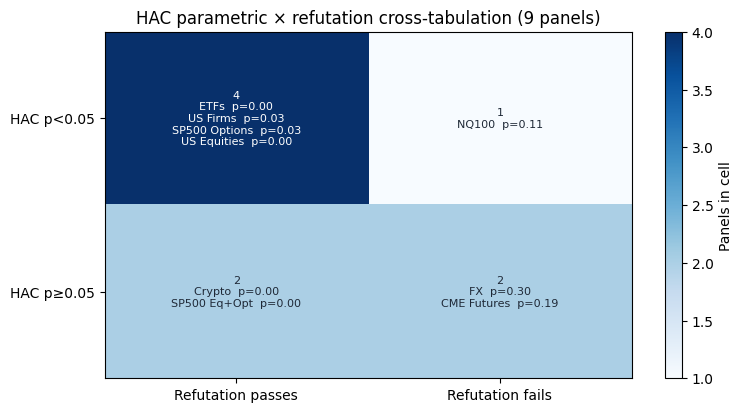

In [23]:
sig_counts = {(sig, ref): 0 for sig in [HAC_SIG, HAC_NOT] for ref in TIER_ORDER}
sig_panels = {key: [] for key in sig_counts}
for r in df_for_table.iter_rows(named=True):
    key = (r["sig_label"], r["refutation_class"])
    sig_counts[key] += 1
    sig_panels[key].append((r["short_name"], r["refutation_p"]))

# 2x2 grid figure
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sig_order = [HAC_SIG, HAC_NOT]
matrix = np.array([[sig_counts[(s, r)] for r in TIER_ORDER] for s in sig_order])
im = ax.imshow(matrix, cmap=plt.cm.Blues, aspect="auto")
for i in range(len(sig_order)):
    for j in range(len(TIER_ORDER)):
        n = matrix[i, j]
        names_p = sig_panels[(sig_order[i], TIER_ORDER[j])]
        text_color = "white" if n > matrix.max() / 2 else "#1f2937"
        if n > 0:
            label = f"{n}\n" + "\n".join(f"{name}  p={p:.2f}" for name, p in names_p)
        else:
            label = "0"
        ax.text(j, i, label, ha="center", va="center", fontsize=8, color=text_color)

ax.set_xticks(range(len(TIER_ORDER)))
ax.set_xticklabels([f"Refutation {c.lower()}" for c in TIER_ORDER])
ax.set_yticks(range(len(sig_order)))
ax.set_yticklabels(sig_order)
ax.set_title(f"HAC parametric × refutation cross-tabulation ({n_with_ref} panels)")
fig.colorbar(im, ax=ax, label="Panels in cell")
fig.show()

In [24]:
def _fmt_panels(items: list[tuple[str, float]]) -> str:
    if not items:
        return "—"
    return ", ".join(f"{name} (p={p:.2f})" for name, p in items)


for sig, sig_disp in [(HAC_SIG, "HAC sig"), (HAC_NOT, "HAC non-sig")]:
    for ref in TIER_ORDER:
        print(f"  {sig_disp} + refutation {ref.lower():6s}: {_fmt_panels(sig_panels[(sig, ref)])}")

  HAC sig + refutation passes: ETFs (p=0.00), US Firms (p=0.03), SP500 Options (p=0.03), US Equities (p=0.00)
  HAC sig + refutation fails : NQ100 (p=0.11)
  HAC non-sig + refutation passes: Crypto (p=0.00), SP500 Eq+Opt (p=0.00)
  HAC non-sig + refutation fails : FX (p=0.30), CME Futures (p=0.19)


Four of the five HAC-significant panels also pass refutation at 5 %:
ETFs ($p_\text{ref} \approx 0.00$), US Equities ($p_\text{ref} \approx
0.00$), US Firms ($p_\text{ref} = 0.03$), and SP500 Options
($p_\text{ref} = 0.03$) — the strongest evidence in this snapshot,
clearing both the parametric and the placebo track at the same
5 % cutoff. NASDAQ-100 is the lone HAC-significant panel that fails
refutation ($p_\text{ref} = 0.11$). Two panels are the inverse
off-diagonal case (HAC non-sig but refutation passes): Crypto
($p_\text{ref} \approx 0.00$) and SP500 Eq+Opt ($p_\text{ref}
\approx 0.00$) — the orthogonalized effect is reproducible against
block-permuted treatments but the HAC standard error is wide enough
to overlap zero. CME Futures ($p_\text{ref} = 0.19$) and FX
($p_\text{ref} = 0.30$) fail on both tracks.

### 7b. Practitioner Rules

Three rules govern how DML estimates plug into the larger predictive
pipeline (Chs 11–13) and the strategy synthesis (Ch 20):

1. **Orthogonalize before reading factor coefficients.** The
   confounding-bias chart shows that naive OLS systematically distorts
   the effect on most panels. Any factor evaluation that skips
   orthogonalization risks reading distortion as signal, including sign
   reversals.
2. **Refutation is non-negotiable, but parametric significance is not
   optional either.** A panel clears both gates at the 5 % level when
   it sits in HAC sig + refutation passes. In this snapshot the
   cell holds four panels (ETFs, US Firms, SP500 Options, US
   Equities). NASDAQ-100 is the lone HAC sig + refutation fails panel:
   parametric significance the permutation track does not confirm.
   Crypto and SP500 Eq+Opt populate the inverse off-diagonal cell
   (HAC non-sig but refutation passes) — the orthogonalized effect is
   reproducible against block-permuted treatments but the HAC
   standard error is too wide for parametric separation from zero.
3. **DML calibrates confidence in predictive IC; it does not displace
   it.** A predictive model that scores well on a panel where DML
   fails refutation should still be deployed with reduced position
   size — the predictive IC may reflect a transient pattern rather
   than a stable causal channel. Conversely, a panel where DML
   passes refutation but the predictive IC is small offers a sizing
   floor for a pure factor-tilt strategy.

Per `feedback_causal_no_backtest`, the causal pipeline is identification-
claim only. The DML estimates above do not enter the backtest stack as
alpha signals; they enter the strategy-construction layer (Ch 20) as
weights on predictive signals, not as predictions in their own right.

## 8. Cross-CS Takeaways

In [25]:
# Recompute the headline counts inline so the takeaways below can cite them.
print(f"Case studies with primary-label causal_runs: {n_loaded} of {n_expected}")
print(f"HAC CI excludes zero (|t_HAC| > {SIG_T:g}): {n_sig} of {n_loaded}")
print(f"  positive effect:  {n_pos_sig}")
print(f"  negative effect:  {n_neg_sig}")
print(f"Median |confounding bias|: {median_abs_bias:.1f} %")
print(f"|bias| > 50 %: {n_large_bias} panels")
print(f"Sign reversals (naive vs DML): {n_reversal} panels")
print(
    f"Refutation outcome counts (primary): {dict(zip(outcome_counts['refutation_class'].to_list(), outcome_counts['n'].to_list(), strict=False))}"
)
print(f"Multi-label panels: {len(multi_cs)} ({', '.join(sorted(multi_cs))})")

Case studies with primary-label causal_runs: 9 of 9
HAC CI excludes zero (|t_HAC| > 1.96): 5 of 9
  positive effect:  2
  negative effect:  3
Median |confounding bias|: 59.7 %
|bias| > 50 %: 5 panels
Sign reversals (naive vs DML): 1 panels
Refutation outcome counts (primary): {'Passes': 6, 'Fails': 3}
Multi-label panels: 8 (CME Futures, Crypto, ETFs, FX, NQ100, SP500 Options, US Equities, US Firms)


- **Coverage and the parametric split.** Causal DML runs are
  registered on the primary label of every case study in the registry
  snapshot used here. The HAC 95 % CI excludes zero on five of the
  nine panels: three with negative orthogonalized effects (ETFs 6-1
  momentum at 21d, SP500 Options VRP at HTM, US Equities 12-1
  momentum at 1d) and two with positive effects (NASDAQ-100
  signed-volume share at 15-min, US Firms 12-2 momentum at 1m). The
  remaining four panels (Crypto, SP500 Eq+Opt, FX, CME Futures at
  primary) carry CIs that overlap zero on the parametric track.
- **Naive OLS systematically misstates the orthogonalized effect.**
  The median absolute confounding bias on the primary label is 59.7 %,
  and |bias| exceeds 50 % on five of the nine panels. The single
  panel above 100 % bias is FX at $-213.5\,\%$. On every panel above
  |bias| = 50 % the naive coefficient cannot be salvaged by rescaling
  — the orthogonalization re-anchors the effect itself, not its
  magnitude.
- **A single sign reversal at the primary label, and it is a wash.**
  FX is the only panel where the naive coefficient and the DML
  estimate carry opposite signs ($-0.0004 \to +0.00036$). The DML CI
  overlaps zero ($t_{HAC}=+0.42$) and refutation also fails
  ($p_\text{ref}=0.30$), so the reversal does not establish a
  credible alternative sign — only that the naive sign is unreliable.
- **The refutation outcome favours pass at 5 %.** Six panels pass
  refutation: ETFs, Crypto, SP500 Eq+Opt, and US Equities at
  $p_\text{ref}\approx 0.00$; US Firms and SP500 Options at
  $p_\text{ref} = 0.03$. Three panels fail: NASDAQ-100
  ($p_\text{ref}=0.11$), CME Futures ($p_\text{ref}=0.19$), FX
  ($p_\text{ref}=0.30$). No panel sits in the $0.05 \leq p < 0.10$
  band — the failures are at $p_\text{ref}\geq 0.11$.
- **The §7a cross-tabulation concentrates the strongest evidence in
  one cell.** Four panels are HAC sig + refutation passes (ETFs, US
  Firms, SP500 Options, US Equities) — both tracks clear at 5 %, the
  most affirmative cell in this snapshot. NASDAQ-100 is the lone
  HAC sig + refutation fails panel: parametrically significant but
  the placebo distribution does not corroborate. Crypto and SP500
  Eq+Opt populate the inverse off-diagonal cell (HAC non-sig + passes
  refutation): orthogonalized effect reproducible against permutations
  but the HAC standard error is too wide for parametric separation
  from zero. CME Futures and FX fail on both tracks.
- **Eight of the nine panels carry multi-horizon causal coverage**
  (only SP500 Eq+Opt is primary-label only). The cleanest horizon
  pattern is ETFs: the 6-1 momentum effect is positive at 5d
  ($t_{HAC}=+6.36$) and negative at 21d ($t_{HAC}=-9.84$), both well
  separated from zero on the parametric track, but only the 21d
  branch passes refutation ($p_\text{ref}=0.00$ vs 5d's
  $p_\text{ref}=1.00$). SP500 Options is sign-stable across all five
  horizons (negative throughout) and HTM is the only cell that clears
  both gates. US Equities is sign-stable across 1d, 5d, 21d but only
  1d clears both gates. CME Futures, FX, Crypto, and NASDAQ-100 do
  not establish parametrically-significant trajectories at any
  secondary horizon.
- **The SP500 Options identification is contingent on accepting the
  confounder set.** The variance risk premium treatment is
  constructed from the same implied-volatility surface that drives
  the held-to-expiry outcome; the included realised-volatility,
  lagged-VRP, and spread controls absorb that dependence to the
  extent they are correctly specified. The both-gates-pass reading on
  this panel should be read with that conditioning in mind.
- **Causal estimates do not enter the backtest stack as alpha
  signals.** Per `feedback_causal_no_backtest`, the DML estimates
  above are identification claims about treatment-outcome
  relationships, not predictions in their own right. They feed Ch 20
  strategy construction as weights on predictive signals; they do not
  replace the predictive models from Chs 11–13.

**Next**: Chapter 16 opens the backtest stack on the predictive signals
evaluated in Chs 11–13; Chapter 20 synthesizes the predictive layer
(Chs 11–13), the latent-factor layer (Ch 14), and the causal weights
(this chapter) into the cross-case-study strategy.

**Book**: Section 15.6 covers cross-dataset causal evidence; Section
15.7 connects the DML reading to strategy construction.

In [26]:
print(f"\n[OK] Cross-dataset causal evaluation complete ({n_loaded}/{n_expected} case studies)")


[OK] Cross-dataset causal evaluation complete (9/9 case studies)
